In [2]:
# Libraries Import

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import silhouette_score

In [4]:
# Load Dataset

df = pd.read_csv("Mall_Customers.csv")

# First 5 rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Mall_Customers.csv'

In [5]:
from google.colab import files

uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [6]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
# Dataset Information

print(df.shape)

df.info()

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
# Missing Values

df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [9]:
# Statistical Summary

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


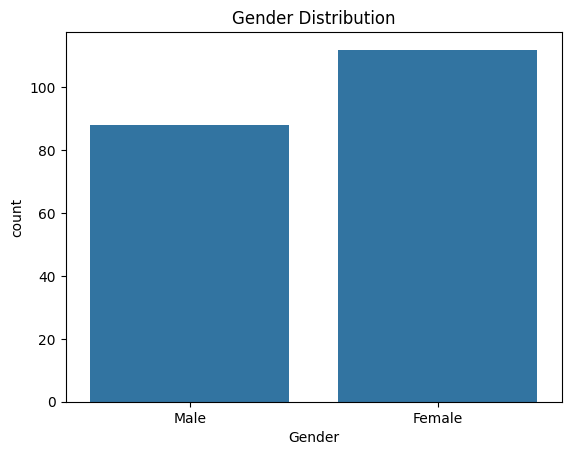

In [10]:
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")

plt.show()

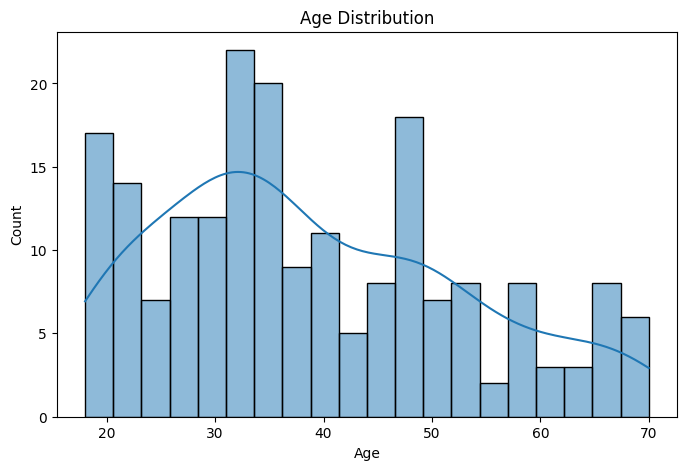

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

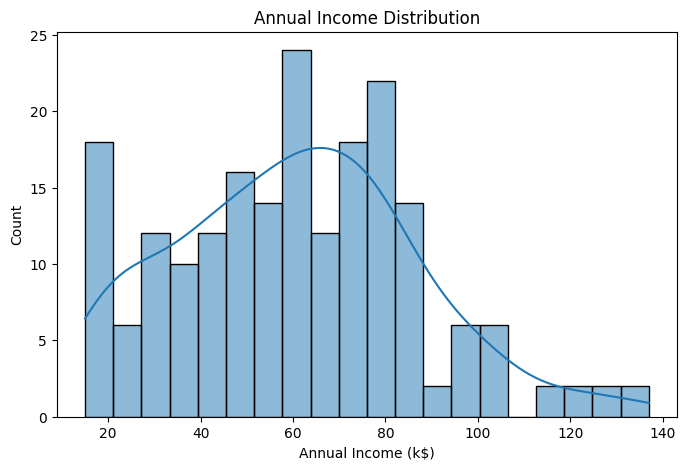

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)

plt.title("Annual Income Distribution")

plt.show()

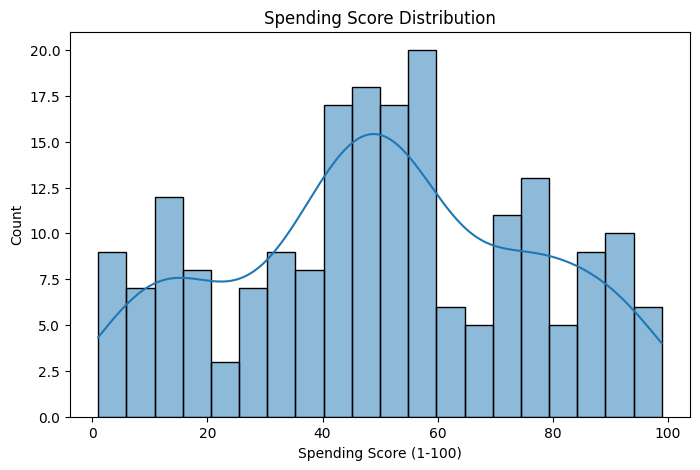

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)

plt.title("Spending Score Distribution")

plt.show()

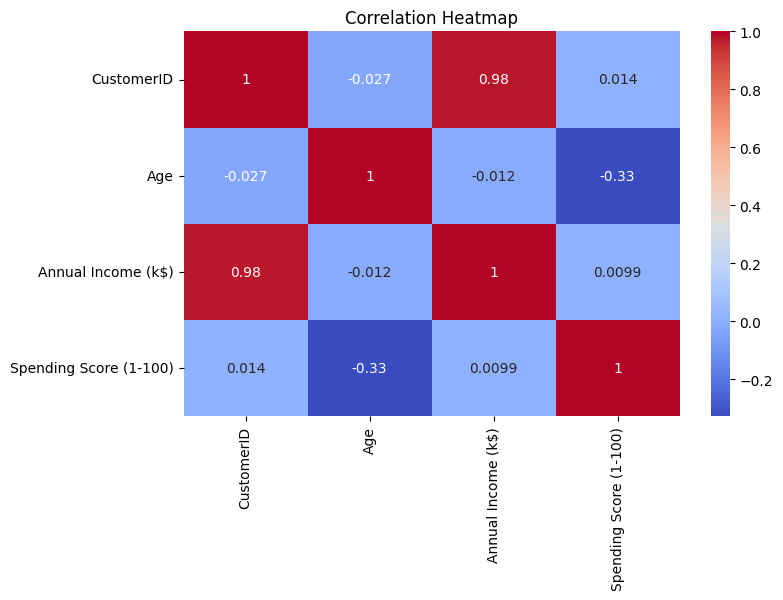

In [14]:
# Selecting only numeric columns

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [15]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

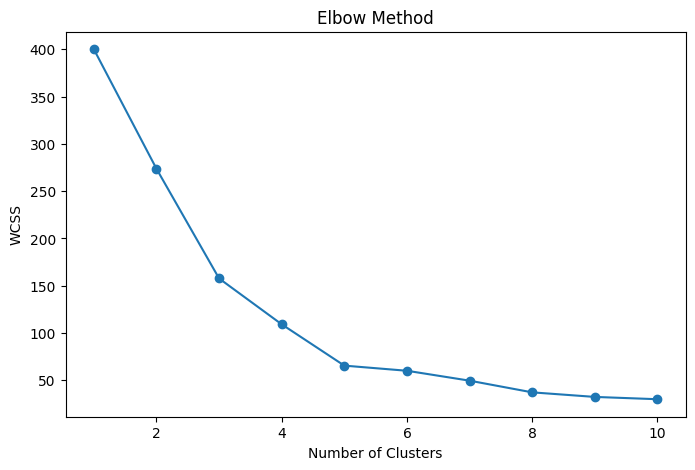

In [17]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [18]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

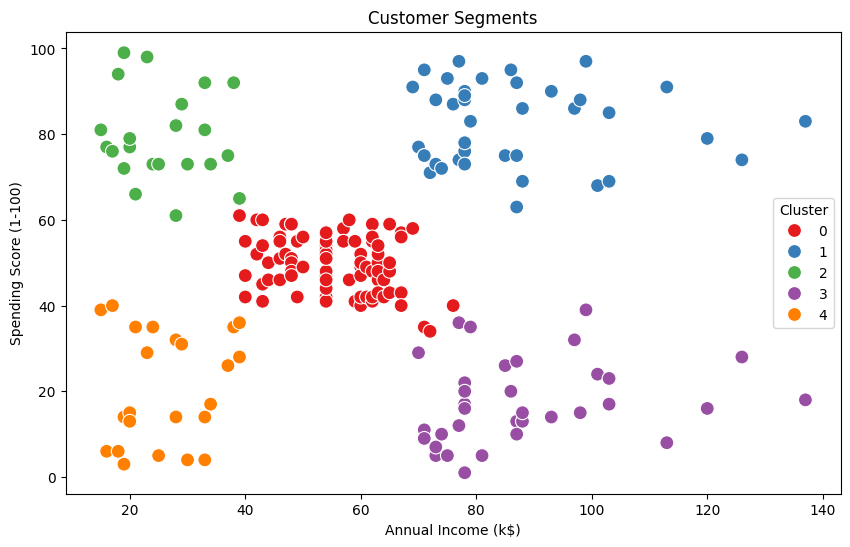

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

plt.title("Customer Segments")

plt.show()

In [20]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


In [21]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=pca_features, columns=['PCA1', 'PCA2'])

pca_df['Cluster'] = clusters

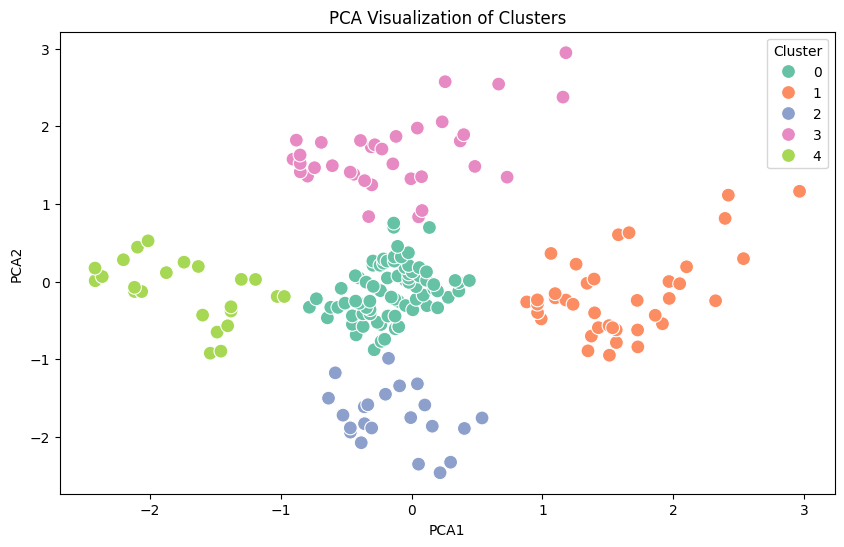

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='Set2',
    s=100
)

plt.title("PCA Visualization of Clusters")

plt.show()

In [23]:
tsne = TSNE(n_components=2, random_state=42)

tsne_features = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(tsne_features, columns=['TSNE1', 'TSNE2'])

tsne_df['Cluster'] = clusters

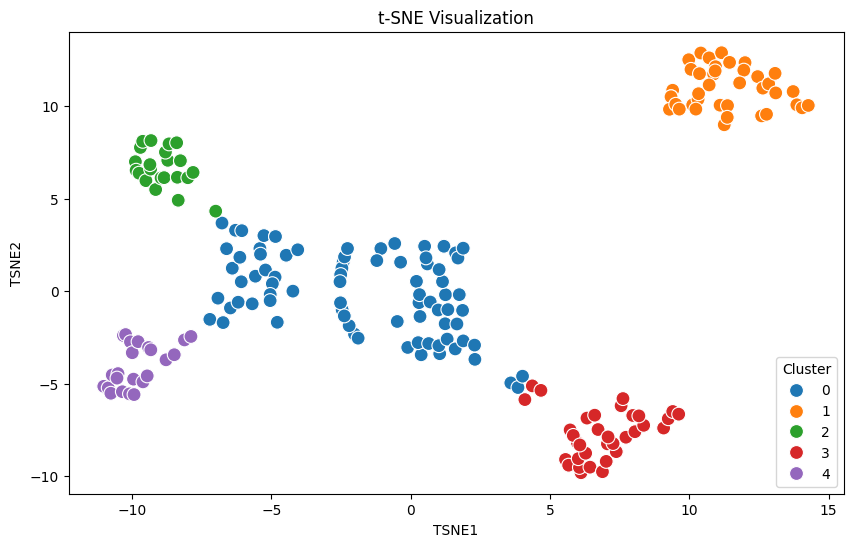

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='Cluster',
    data=tsne_df,
    palette='tab10',
    s=100
)

plt.title("t-SNE Visualization")

plt.show()

## Customer Segments Analysis

### Cluster 0
- Medium income
- Medium spending
- Regular customers

### Cluster 1
- High income
- High spending
- Premium customers

### Cluster 2
- Low income
- Low spending
- Budget-conscious customers

### Cluster 3
- High income
- Low spending
- Careful customers

### Cluster 4
- Low income
- High spending
- Impulsive buyers

# Marketing Strategies

## Premium Customers
- Offer VIP memberships
- Exclusive discounts
- Loyalty rewards

## Budget Customers
- Provide affordable offers
- Bundle discounts
- Seasonal sales

## Careful Customers
- Personalized recommendations
- Cashback offers

## Impulsive Buyers
- Limited-time deals
- Social media promotions

## Regular Customers
- Retention campaigns
- Email marketing